## Cell 1: Imports and file path


In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import random
import os

datafile = "weather_data.csv"


## Cell 2 - Problem 1: Linear Regression using Normal Equation


In [13]:
def normal_equation_line(x, y):
    x = np.asarray(x, dtype=np.float64).reshape(-1, 1)
    y = np.asarray(y, dtype=np.float64).reshape(-1, 1)

    X = np.hstack([np.ones((x.shape[0], 1)), x])
    theta = np.linalg.inv(X.T @ X) @ (X.T @ y)

    return float(theta[0, 0]), float(theta[1, 0])

def predict_line(theta0, theta1, x_values):
    x_values = np.asarray(x_values, dtype=np.float64)
    return theta0 + theta1 * x_values

## Cell 3: Problem 1 detailed computation and output


In [14]:
marks = np.array([95, 85, 80, 70, 60], dtype=np.float64)
grades = np.array([85, 95, 70, 65, 70], dtype=np.float64)

# Step 1: Build X and y
X = np.c_[np.ones((len(marks), 1)), marks.reshape(-1, 1)]
y = grades.reshape(-1, 1)

# Step 2: Compute X^T X
XtX = X.T @ X

# Step 3: Compute X^T y
Xty = X.T @ y

# Step 4: Compute theta
theta = np.linalg.inv(XtX) @ Xty
theta0, theta1 = float(theta[0, 0]), float(theta[1, 0])

print("=== Problem 1: Normal Equation (Detailed Steps) ===")
print("X =\n", X)
print("y =\n", y)
print("\nX^T X =\n", XtX)
print("\nX^T y =\n", Xty)
print("\nTheta =\n", theta)

print("\nFinal line equation:")
print(f"y_hat = {theta0:.6f} + {theta1:.6f}x")

# Predictions
given_marks = [65, 75, 77, 83, 87]
preds = predict_line(theta0, theta1, given_marks)

print("\nPredicted grades:")
for m, p in zip(given_marks, preds):
    print(f"Marks {m} -> Predicted Grade {p:.4f}")


=== Problem 1: Normal Equation (Detailed Steps) ===
X =
 [[ 1. 95.]
 [ 1. 85.]
 [ 1. 80.]
 [ 1. 70.]
 [ 1. 60.]]
y =
 [[85.]
 [95.]
 [70.]
 [65.]
 [70.]]

X^T X =
 [[5.000e+00 3.900e+02]
 [3.900e+02 3.115e+04]]

X^T y =
 [[  385.]
 [30500.]]

Theta =
 [[26.78082192]
 [ 0.64383562]]

Final line equation:
y_hat = 26.780822 + 0.643836x

Predicted grades:
Marks 65 -> Predicted Grade 68.6301
Marks 75 -> Predicted Grade 75.0685
Marks 77 -> Predicted Grade 76.3562
Marks 83 -> Predicted Grade 80.2192
Marks 87 -> Predicted Grade 82.7945


## Cell 4: Problem 2: Load and Split data

In [15]:
def get_data(filename):
    if not os.path.exists(filename):
        raise FileNotFoundError(f"Cannot find file: {filename}")

    df = pd.read_csv(filename)

    X_ = df[["Humidity", "Visibility (km)"]].values.astype(np.float64)
    Y_ = df[["Temperature (C)"]].values.astype(np.float64)

    X_train, X_test, y_train, y_test = train_test_split(
        X_, Y_, test_size=0.25, random_state=42
    )
    return X_train, X_test, y_train, y_test

X_train, X_test, y_train, y_test = get_data(datafile)
print("Shapes:", X_train.shape, X_test.shape, y_train.shape, y_test.shape)


Shapes: (72321, 2) (24108, 2) (72321, 1) (24108, 1)


## Cell 5 - Required functions (a-f)

In [16]:
def data_iter(batch_size, X, y):
    num_examples = len(X)
    indices = list(range(num_examples))
    random.shuffle(indices)

    for i in range(0, num_examples, batch_size):
        batch_idx = indices[i:i + batch_size]
        yield X[batch_idx], y[batch_idx]

def create_model_parameter(mu, sigma, row, column):
    w = np.random.normal(mu, sigma, size=(row, column))
    b = np.zeros((1, column))
    return w, b

def model(X, w, b):
    return X @ w + b

def squared_loss(y_hat, y):
    return 0.5 * np.mean((y_hat - y) ** 2)

def gradient(X, y, w, b):
    m = X.shape[0]
    y_hat = model(X, w, b)
    err = y_hat - y
    grad_w = (X.T @ err) / m
    grad_b = np.sum(err, axis=0, keepdims=True) / m
    return grad_w, grad_b

def sgd(params, grads, lr):
    w, b = params
    grad_w, grad_b = grads
    w = w - lr * grad_w
    b = b - lr * grad_b
    return w, b


## Cell 6 - Standardization helpers

In [17]:
def standardize_fit(X):
    mu = X.mean(axis=0, keepdims=True)
    sigma = X.std(axis=0, keepdims=True) + 1e-12
    return mu, sigma

def standardize_transform(X, mu, sigma):
    return (X - mu) / sigma


## Cell 7 - Train function (g)

In [18]:
def train(lr, num_epochs, X_train, y_train, batch_size, seed=42):
    random.seed(seed)
    np.random.seed(seed)

    Xmu, Xsig = standardize_fit(X_train)
    Xs = standardize_transform(X_train, Xmu, Xsig)

    w, b = create_model_parameter(mu=0.0, sigma=0.01, row=Xs.shape[1], column=1)

    losses = []
    for epoch in range(num_epochs):
        for Xb, yb in data_iter(batch_size, Xs, y_train):
            grads = gradient(Xb, yb, w, b)
            w, b = sgd((w, b), grads, lr)

        train_loss = squared_loss(model(Xs, w, b), y_train)
        losses.append(train_loss)
        print(f"epoch {epoch + 1:02d}, batch {batch_size:<6}, loss {train_loss:.6f}")

    return (w, b, Xmu, Xsig), losses

def predict(X, params_pack):
    w, b, Xmu, Xsig = params_pack
    Xs = standardize_transform(X, Xmu, Xsig)
    return model(Xs, w, b)


## Cell 8 - Train 3 batch sizes (h) and plot Train loss VS Epoch


--- Training SMALL batch ---
epoch 01, batch 32    , loss 0.007753
epoch 02, batch 32    , loss 0.008037
epoch 03, batch 32    , loss 0.007721
epoch 04, batch 32    , loss 0.007815
epoch 05, batch 32    , loss 0.007779
epoch 06, batch 32    , loss 0.007709
epoch 07, batch 32    , loss 0.008162
epoch 08, batch 32    , loss 0.008653
epoch 09, batch 32    , loss 0.007828
epoch 10, batch 32    , loss 0.007854
epoch 11, batch 32    , loss 0.007736
epoch 12, batch 32    , loss 0.008706
epoch 13, batch 32    , loss 0.007738
epoch 14, batch 32    , loss 0.007770
epoch 15, batch 32    , loss 0.007792
epoch 16, batch 32    , loss 0.008044
epoch 17, batch 32    , loss 0.009423
epoch 18, batch 32    , loss 0.007765
epoch 19, batch 32    , loss 0.008285
epoch 20, batch 32    , loss 0.007899
epoch 21, batch 32    , loss 0.007725
epoch 22, batch 32    , loss 0.007787
epoch 23, batch 32    , loss 0.007723
epoch 24, batch 32    , loss 0.008116
epoch 25, batch 32    , loss 0.007771
epoch 26, batch 32  

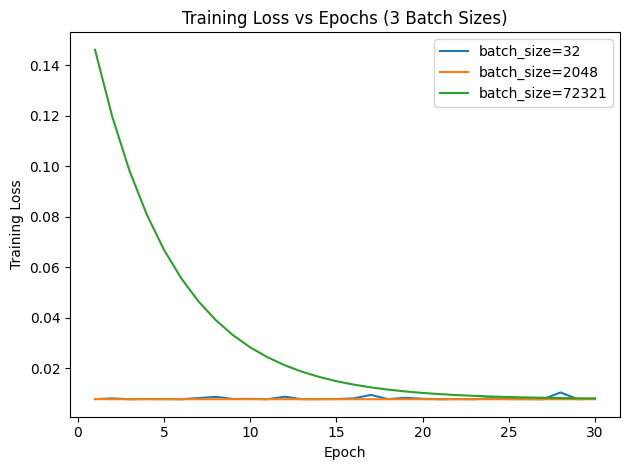

In [19]:
def draw_loss(loss_dict):
    plt.figure()
    for bs, losses in loss_dict.items():
        epochs = np.arange(1, len(losses) + 1)
        plt.plot(epochs, losses, label=f"batch_size={bs}")

    plt.xlabel("Epoch")
    plt.ylabel("Training Loss")
    plt.title("Training Loss vs Epochs (3 Batch Sizes)")
    plt.legend()
    plt.tight_layout()
    plt.show()

lr = 0.1
num_epochs = 30

bs_small = 32
bs_large = 2048
bs_exact = X_train.shape[0]

print("\n--- Training SMALL batch ---")
params_small, losses_small = train(lr, num_epochs, X_train, y_train, bs_small)

print("\n--- Training LARGE batch ---")
params_large, losses_large = train(lr, num_epochs, X_train, y_train, bs_large)

print("\n--- Training EXACT (full) batch ---")
params_exact, losses_exact = train(lr, num_epochs, X_train, y_train, bs_exact)

draw_loss({
    bs_small: losses_small,
    bs_large: losses_large,
    bs_exact: losses_exact
})


## Cell 9 - Batch size explanation

In [20]:
print("Effect of Batch Sizes on Training Loss:")
print("- Small batch: more parameter updates per epoch → often faster learning but noisier curve.")
print("- Large batch: fewer updates → smoother curve, may improve more slowly per epoch.")
print("- Exact/full batch: smoothest curve, but each update uses all data and updates are less frequent.")


Effect of Batch Sizes on Training Loss:
- Small batch: more parameter updates per epoch → often faster learning but noisier curve.
- Large batch: fewer updates → smoother curve, may improve more slowly per epoch.
- Exact/full batch: smoothest curve, but each update uses all data and updates are less frequent.


## Cell 10 - Test Evaluation output

In [22]:
y_pred = predict(X_test, params_small)
test_mse = np.mean((y_pred - y_test) ** 2)
print(f"Test MSE (using small batch model) = {test_mse:.6f}")

print("\nSample predictions (first 5):")
for i in range(min(5, len(y_test))):
    print(f"X={X_test[i]} | y_true={y_test[i,0]:.3f} | y_pred={y_pred[i,0]:.3f}")


Test MSE (using small batch model) = 0.015959

Sample predictions (first 5):
X=[0.82  0.643] | y_true=0.563 | y_pred=0.529
X=[0.96 0.04] | y_true=0.408 | y_pred=0.419
X=[0.9   0.983] | y_true=0.677 | y_pred=0.531
X=[0.85  0.056] | y_true=0.277 | y_pred=0.462
X=[0.49  0.966] | y_true=0.823 | y_pred=0.683
